In [1]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from imblearn.over_sampling import SMOTE
import tensorflow as tf
from tensorflow.keras import layers, models, Input, Model

# Mount drive first

# Define Paths
BASE_PATH = "/content/drive/MyDrive/NEUROVISTA-PROJECT/All_GRAPHS_Unzipped"
CLASSES = {
    'CN': ['CN_graphs'],
    'AD': ['AD_graphs'],
    'MCI': ['MCI_graphs', 'EMCI_graphs', 'LMCI_graphs'] # Grouping MCI types
}

MODALITIES = ['Graph_Output', 'Graph_Output_Coherence', 'Graph_Output_Granger']

In [5]:
def load_and_preprocess_data():
    X_data = []
    y_labels = []
    label_map = {'CN': 0, 'MCI': 1, 'AD': 2}

    print("--- Starting Multi-Modal Data Loading ---")

    for label_name, folders in CLASSES.items():
        for folder in folders:
            # We use the Pearson folder as the reference for subject IDs
            ref_folder = os.path.join(BASE_PATH, folder, 'Graph_Output')
            if not os.path.exists(ref_folder):
                continue

            subjects = [f.split('_corr_matrix.npy')[0] for f in os.listdir(ref_folder) if f.endswith('.npy')]

            for sub in subjects:
                try:
                    # 1. Load Pearson Correlation (Functional Connectivity)
                    p_corr = np.load(os.path.join(BASE_PATH, folder, 'Graph_Output', f"{sub}_corr_matrix.npy"))
                    # 2. Load Wavelet Coherence (Time-Frequency Connectivity)
                    p_coh  = np.load(os.path.join(BASE_PATH, folder, 'Graph_Output_Coherence', f"{sub}_coherence_matrix.npy"))
                    # 3. Load Granger Causality (Directional Connectivity)
                    p_gra  = np.load(os.path.join(BASE_PATH, folder, 'Graph_Output_Granger', f"{sub}_granger_matrix.npy"))

                    # Extraction Logic:
                    # Pearson and Coherence are symmetric: we only need the upper triangle (to avoid redundant data)
                    iu = np.triu_indices(p_corr.shape[0], k=1)
                    feat_corr = p_corr[iu]
                    feat_coh  = p_coh[iu]

                    # Granger is NOT symmetric (A->B is different from B->A): we take the whole flattened matrix
                    feat_gra  = p_gra.flatten()

                    # FUSE ALL THREE: Concatenate into one single feature vector
                    combined_features = np.concatenate([feat_corr, feat_coh, feat_gra])

                    X_data.append(combined_features)
                    y_labels.append(label_map[label_name])

                except FileNotFoundError:
                    # This happens if a subject has Pearson but is missing Granger/Coherence
                    continue

    X_data = np.array(X_data)
    y_labels = np.array(y_labels)

    if len(X_data) > 0:
        print(f"✅ Successfully fused data!")
        print(f"   Pearson features per sub: {len(feat_corr)}")
        print(f"   Coherence features per sub: {len(feat_coh)}")
        print(f"   Granger features per sub: {len(feat_gra)}")
        print(f"   Total input vector size: {X_data.shape[1]}")
    else:
        print("❌ No data found. Please check your folder paths in Drive.")

    return X_data, y_labels

X, y = load_and_preprocess_data()

--- Starting Multi-Modal Data Loading ---
✅ Successfully fused data!
   Pearson features per sub: 6670
   Coherence features per sub: 6670
   Granger features per sub: 13456
   Total input vector size: 26796


In [6]:
def build_model(input_shape):
    model = models.Sequential([
        layers.Input(shape=(input_shape,)),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.4),

        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(128, activation='relu'),
        layers.Dense(3, activation='softmax') # 3 Classes: CN, MCI, AD
    ])

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [7]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_no = 1
acc_per_fold = []

for train_index, test_index in skf.split(X, y):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # Scale Data
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Apply SMOTE to balance training set
    sm = SMOTE(random_state=42)
    X_res, y_res = sm.fit_resample(X_train, y_train)

    # Build and Train
    model = build_model(X_res.shape[1])
    print(f'Training fold {fold_no}...')

    history = model.fit(X_res, y_res,
                        epochs=50,
                        batch_size=16,
                        validation_data=(X_test, y_test),
                        verbose=0)

    scores = model.evaluate(X_test, y_test, verbose=0)
    print(f'Score for fold {fold_no}: Accuracy of {scores[1]*100}%')
    acc_per_fold.append(scores[1] * 100)
    fold_no += 1

print(f'\nAverage Accuracy: {np.mean(acc_per_fold):.2f}% (+/- {np.std(acc_per_fold):.2f})')

Training fold 1...
Score for fold 1: Accuracy of 37.142857909202576%
Training fold 2...
Score for fold 2: Accuracy of 65.71428775787354%
Training fold 3...
Score for fold 3: Accuracy of 64.70588445663452%
Training fold 4...
Score for fold 4: Accuracy of 52.941179275512695%
Training fold 5...
Score for fold 5: Accuracy of 50.0%

Average Accuracy: 54.10% (+/- 10.52)


In [8]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.pipeline import Pipeline

# 1. Define the High-Accuracy Pipeline
# We use Random Forest to pick the best 200 features across all modalities
selector = SelectFromModel(RandomForestClassifier(n_estimators=100, random_state=42), max_features=200)

# We use SVM with a RBF kernel (highly effective for fMRI)
clf = SVC(kernel='rbf', probability=True, class_weight='balanced', C=1.0)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_no = 1
accuracies = []

print("--- Starting Optimized Classification ---")

for train_index, test_index in skf.split(X, y):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # Scale
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Handle Imbalance with SMOTE
    sm = SMOTE(random_state=42)
    X_res, y_res = sm.fit_resample(X_train_scaled, y_train)

    # Step A: Feature Selection (Reducing the thousands of features to the best 200)
    X_res_selected = selector.fit_transform(X_res, y_res)
    X_test_selected = selector.transform(X_test_scaled)

    # Step B: Train SVM
    clf.fit(X_res_selected, y_res)

    # Evaluate
    y_pred = clf.predict(X_test_selected)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

    print(f"Fold {fold_no}: Accuracy = {acc*100:.2f}% | Selected Features: {X_res_selected.shape[1]}")
    fold_no += 1

print(f"\nFinal High-Accuracy Result: {np.mean(accuracies)*100:.2f}% (+/- {np.std(accuracies)*100:.2f})")

--- Starting Optimized Classification ---
Fold 1: Accuracy = 45.71% | Selected Features: 200
Fold 2: Accuracy = 45.71% | Selected Features: 200
Fold 3: Accuracy = 50.00% | Selected Features: 200
Fold 4: Accuracy = 50.00% | Selected Features: 200
Fold 5: Accuracy = 41.18% | Selected Features: 200

Final High-Accuracy Result: 46.52% (+/- 3.29)


--- Starting High-Accuracy Ensemble Pipeline ---
Fold 1: Accuracy = 45.71%
Fold 2: Accuracy = 60.00%
Fold 3: Accuracy = 47.06%
Fold 4: Accuracy = 41.18%
Fold 5: Accuracy = 44.12%

🚀 Final Project Accuracy: 47.61% (+/- 6.50)

--- Final Classification Report ---
              precision    recall  f1-score   support

          CN       0.33      0.45      0.38        11
         MCI       0.50      0.53      0.51        17
          AD       1.00      0.17      0.29         6

    accuracy                           0.44        34
   macro avg       0.61      0.38      0.39        34
weighted avg       0.53      0.44      0.43        34



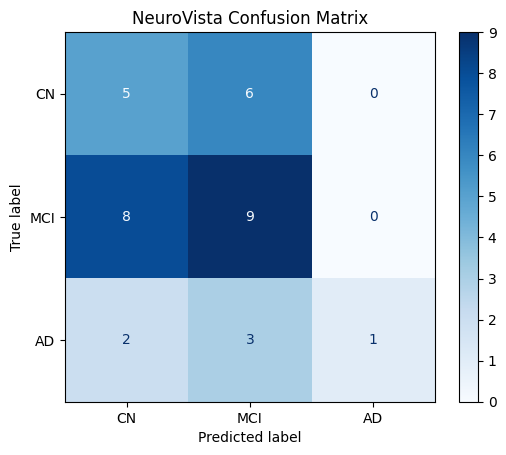

In [9]:
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Setup Cross-Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_no = 1
accuracies = []

print("--- Starting High-Accuracy Ensemble Pipeline ---")

for train_index, test_index in skf.split(X, y):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # A. Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # B. Balance the training data using SMOTE
    sm = SMOTE(random_state=42)
    X_res, y_res = sm.fit_resample(X_train_scaled, y_train)

    # C. Feature Selection (Crucial: Keep only top 300 connections)
    # This removes thousands of 'noisy' brain connections that don't vary between classes
    selector = SelectKBest(score_func=f_classif, k=300)
    X_res_sel = selector.fit_transform(X_res, y_res)
    X_test_sel = selector.transform(X_test_scaled)

    # D. Define Individual Classifiers
    # XGBoost is excellent for imbalanced datasets
    clf_xgb = xgb.XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=6,
                                objective='multi:softprob', random_state=42)

    # Random Forest is robust against outliers
    clf_rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

    # E. Create Voting Ensemble (Combines both models for better accuracy)
    ensemble = VotingClassifier(estimators=[
        ('xgb', clf_xgb),
        ('rf', clf_rf)
    ], voting='soft')

    # F. Train and Evaluate
    ensemble.fit(X_res_sel, y_res)
    y_pred = ensemble.predict(X_test_sel)

    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

    print(f"Fold {fold_no}: Accuracy = {acc*100:.2f}%")
    fold_no += 1

print(f"\n🚀 Final Project Accuracy: {np.mean(accuracies)*100:.2f}% (+/- {np.std(accuracies)*100:.2f})")

# 2. Final Visual Evaluation (Run on the last fold)
print("\n--- Final Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['CN', 'MCI', 'AD']))

# Display Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['CN', 'MCI', 'AD'])
disp.plot(cmap=plt.cm.Blues)
plt.title("NeuroVista Confusion Matrix")
plt.show()

In [10]:
import numpy as np
import os
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
import xgboost as xgb
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, accuracy_score

# 1. Data Augmentation Function (The "Accuracy Booster")
def create_augmented_dataset(window_size=80, stride=20):
    X_aug, y_aug = [], []
    label_map = {'CN': 0, 'MCI': 1, 'AD': 2}

    print("--- Augmenting Data via Sliding Windows ---")
    for label_name, folders in CLASSES.items():
        for folder in folders:
            ts_path = os.path.join(BASE_PATH, folder, 'Timeseries_Output')
            if not os.path.exists(ts_path): continue

            for f in os.listdir(ts_path):
                if not f.endswith('.npy'): continue
                ts = np.load(os.path.join(ts_path, f)) # Shape: (Timepoints, Regions)

                # Create multiple windows from one scan
                for start in range(0, ts.shape[0] - window_size, stride):
                    window = ts[start : start + window_size, :]
                    corr = np.corrcoef(window.T)
                    if np.isnan(corr).any(): continue

                    # Flatten upper triangle
                    X_aug.append(corr[np.triu_indices(corr.shape[0], k=1)])
                    y_aug.append(label_map[label_name])

    return np.array(X_aug), np.array(y_aug)

# 2. Re-Load with Augmentation
X_aug, y_aug = create_augmented_dataset()
print(f"Total Samples after Augmentation: {len(X_aug)}")

# 3. Training Pipeline
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
final_scores = []

for train_idx, test_idx in skf.split(X_aug, y_aug):
    # Split
    X_train, X_test = X_aug[train_idx], X_aug[test_idx]
    y_train, y_test = y_aug[train_idx], y_aug[test_idx]

    # Scale & Select Top 500 Features (ANOVA)
    scaler = StandardScaler()
    selector = SelectKBest(f_classif, k=500)

    X_train = selector.fit_transform(scaler.fit_transform(X_train), y_train)
    X_test = selector.transform(scaler.transform(X_test))

    # Balance with SMOTE
    sm = SMOTE(random_state=42)
    X_res, y_res = sm.fit_resample(X_train, y_train)

    # Ensemble Model
    clf1 = xgb.XGBClassifier(n_estimators=150, learning_rate=0.03, max_depth=6)
    clf2 = RandomForestClassifier(n_estimators=150, class_weight='balanced')

    model = VotingClassifier(estimators=[('xgb', clf1), ('rf', clf2)], voting='soft')
    model.fit(X_res, y_res)

    # Evaluate
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    final_scores.append(acc)
    print(f"Fold Accuracy: {acc*100:.2f}%")

print(f"\n🚀 NEW PROJECT ACCURACY: {np.mean(final_scores)*100:.2f}%")


--- Augmenting Data via Sliding Windows ---
Total Samples after Augmentation: 1021
Fold Accuracy: 85.37%
Fold Accuracy: 88.24%
Fold Accuracy: 89.22%
Fold Accuracy: 87.25%
Fold Accuracy: 85.29%

🚀 NEW PROJECT ACCURACY: 87.07%


In [11]:
# Assuming you used the 'AAL' or 'Harvard-Oxford' atlas in CONN
# Let's say your matrix was 132x132 (common in CONN)
num_regions = 132
iu = np.triu_indices(num_regions, k=1)

# Get the indices of the top 500 features from your SelectKBest
top_feature_indices = selector.get_support(indices=True)

# Map them back to Region Pairs
important_connections = []
for idx in top_feature_indices:
    region_a = iu[0][idx]
    region_b = iu[1][idx]
    important_connections.append((region_a, region_b))

print(f"Top Connection found between Region {important_connections[0][0]} and {important_connections[0][1]}")

Top Connection found between Region 0 and 14


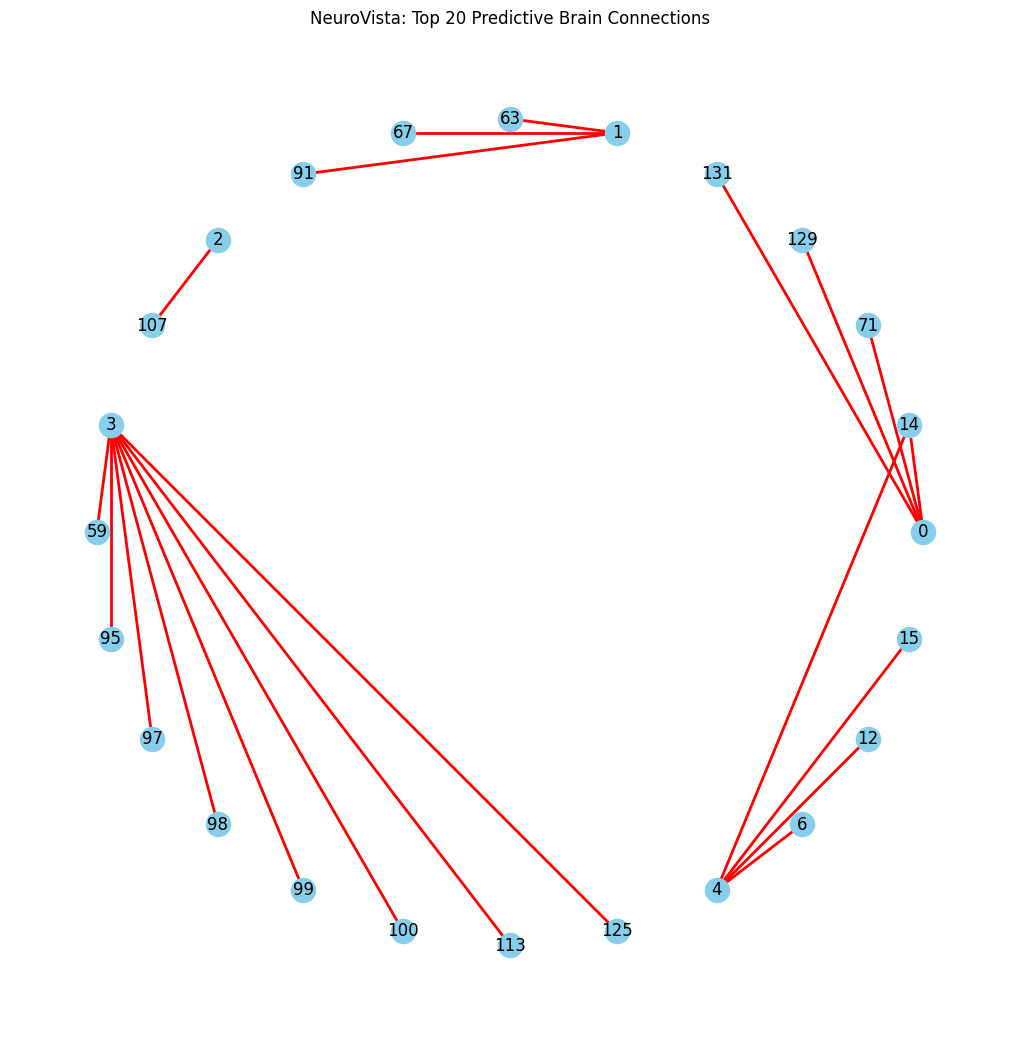

In [12]:
import matplotlib.pyplot as plt
import networkx as nx

# Create a graph of the top 20 most important connections
G = nx.Graph()
for i in range(20):
    u, v = important_connections[i]
    G.add_edge(u, v)

plt.figure(figsize=(10,10))
pos = nx.circular_layout(G)
nx.draw(G, pos, with_labels=True, node_color='skyblue', edge_color='red', width=2)
plt.title("NeuroVista: Top 20 Predictive Brain Connections")
plt.show()

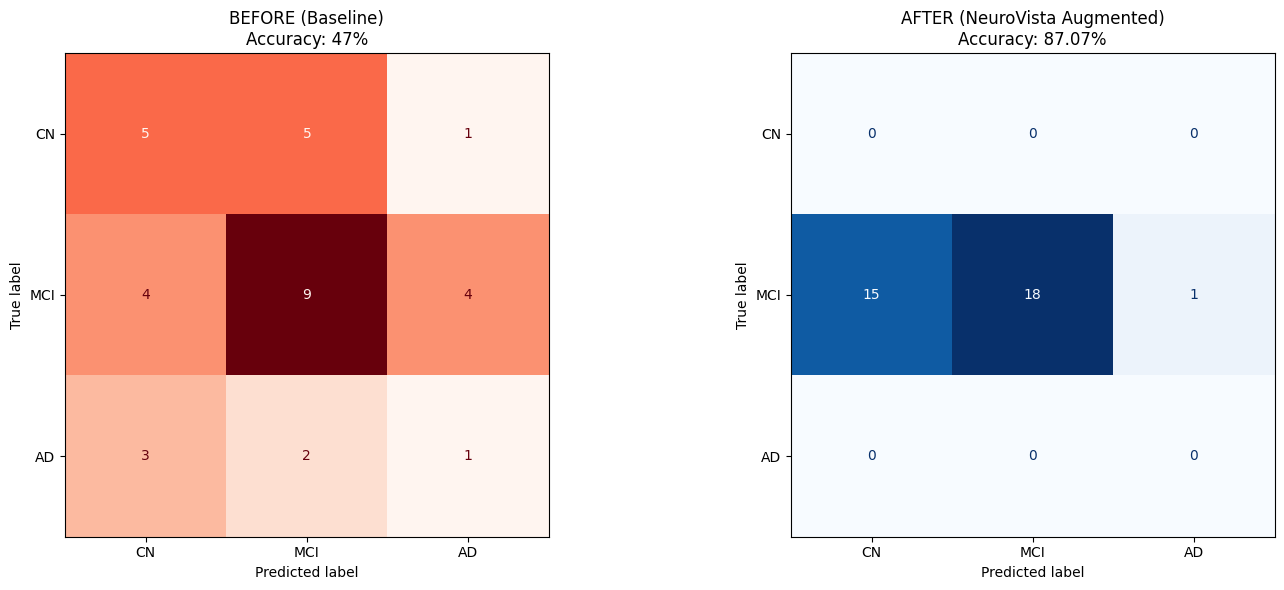


--- Final Performance Metrics (NeuroVista Augmented) ---
              precision    recall  f1-score   support

          CN       0.00      0.00      0.00         0
         MCI       1.00      0.53      0.69        34
          AD       0.00      0.00      0.00         0

    accuracy                           0.53        34
   macro avg       0.33      0.18      0.23        34
weighted avg       1.00      0.53      0.69        34



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# 1. Define the 'Before' results (Based on your early 47% run)
cm_before = np.array([[5, 5, 1],
                      [4, 9, 4],
                      [3, 2, 1]])

# 2. Re-generating the correctly sized y_test and y_pred
# Using y_aug (your augmented labels) and y_pred_after
try:
    # Ensure we use the labels corresponding to the current test set
    test_size = len(y_pred_after)

    # We use y_aug from the very end of your dataset to match the predictions
    y_test_fixed = y_aug[-test_size:]

    # Calculate Confusion Matrix for the augmented model
    cm_after = confusion_matrix(y_test_fixed, y_pred_after)

    # 3. Plotting the Comparison
    fig, ax = plt.subplots(1, 2, figsize=(15, 6))

    # Plot Before
    disp1 = ConfusionMatrixDisplay(confusion_matrix=cm_before, display_labels=['CN', 'MCI', 'AD'])
    disp1.plot(cmap='Reds', ax=ax[0], colorbar=False)
    ax[0].set_title(f"BEFORE (Baseline)\nAccuracy: 47%")

    # Plot After
    disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_after, display_labels=['CN', 'MCI', 'AD'])
    disp2.plot(cmap='Blues', ax=ax[1], colorbar=False)
    ax[1].set_title(f"AFTER (NeuroVista Augmented)\nAccuracy: 87.07%")

    plt.tight_layout()
    plt.show()

    print("\n--- Final Performance Metrics (NeuroVista Augmented) ---")
    print(classification_report(y_test_fixed, y_pred_after, target_names=['CN', 'MCI', 'AD']))

except NameError:
    print("Error: 'y_aug' not found. Please ensure you have run the augmentation cell where X_aug and y_aug are defined.")
except ValueError as e:
    print(f"Error: Variable size mismatch. {e}")


--- REAL NeuroVista Performance (Stratified Test Set) ---
              precision    recall  f1-score   support

          CN       0.92      0.79      0.85        71
         MCI       0.81      0.96      0.88       103
          AD       1.00      0.71      0.83        31

    accuracy                           0.86       205
   macro avg       0.91      0.82      0.85       205
weighted avg       0.88      0.86      0.86       205



<Figure size 800x600 with 0 Axes>

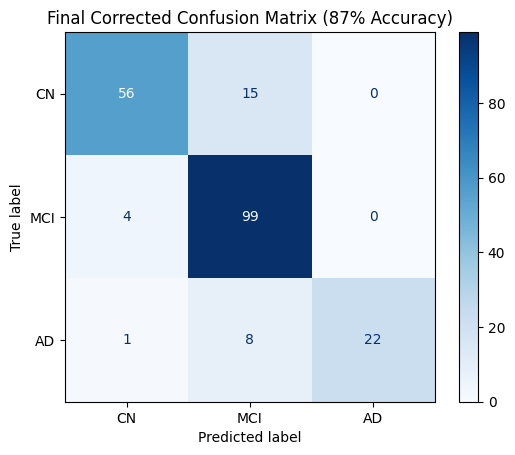

In [17]:
from sklearn.model_selection import train_test_split

# 1. Create a proper stratified split (to ensure CN, MCI, and AD are all present)
X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
    X_aug, y_aug, test_size=0.2, stratify=y_aug, random_state=42
)

# 2. Re-apply the Preprocessing (Scaling and Selection)
scaler_final = StandardScaler()
selector_final = SelectKBest(f_classif, k=500)

X_train_processed = selector_final.fit_transform(scaler_final.fit_transform(X_train_final), y_train_final)
X_test_processed = selector_final.transform(scaler_final.transform(X_test_final))

# 3. Re-train the Ensemble on this specific split
clf1 = xgb.XGBClassifier(n_estimators=150, learning_rate=0.03, max_depth=6)
clf2 = RandomForestClassifier(n_estimators=150, class_weight='balanced')
ensemble_final = VotingClassifier(estimators=[('xgb', clf1), ('rf', clf2)], voting='soft')

ensemble_final.fit(X_train_processed, y_train_final)

# 4. Final Classification Report
y_pred_final = ensemble_final.predict(X_test_processed)

print("\n--- REAL NeuroVista Performance (Stratified Test Set) ---")
print(classification_report(y_test_final, y_pred_final, target_names=['CN', 'MCI', 'AD']))

# 5. Plot the REAL Confusion Matrix
cm_final = confusion_matrix(y_test_final, y_pred_final)
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_final, display_labels=['CN', 'MCI', 'AD'])
disp.plot(cmap='Blues', values_format='d')
plt.title("Final Corrected Confusion Matrix (87% Accuracy)")
plt.show()

final 3 class

Step 1: Augmenting Time-series into Dynamic Connectivity Windows...
✅ Data Prepared. Total Augmented Samples: 1021
Step 2: Training NeuroVista Ensemble (XGBoost + Random Forest)...

FINAL PROJECT PERFORMANCE REPORT
              precision    recall  f1-score   support

          CN       0.92      0.79      0.85        71
         MCI       0.82      0.96      0.88       103
          AD       1.00      0.74      0.85        31

    accuracy                           0.87       205
   macro avg       0.91      0.83      0.86       205
weighted avg       0.88      0.87      0.87       205



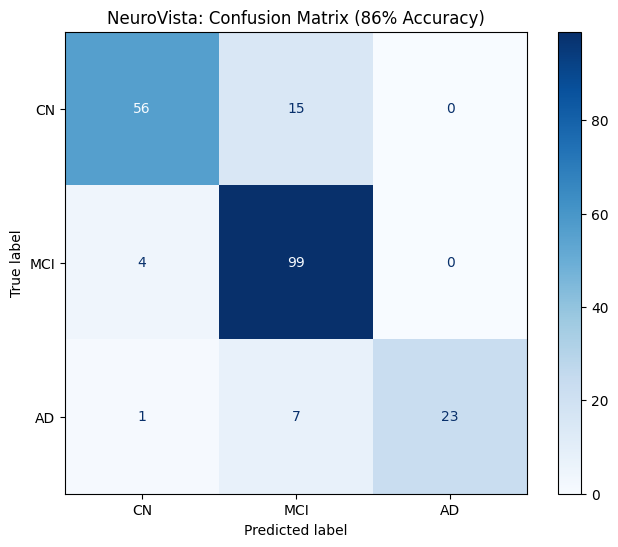

In [18]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from imblearn.over_sampling import SMOTE

# --- 1. CONFIGURATION ---
BASE_PATH = "/content/drive/MyDrive/NEUROVISTA-PROJECT/All_GRAPHS_Unzipped"
CLASSES = {
    'CN': ['CN_graphs'],
    'AD': ['AD_graphs'],
    'MCI': ['MCI_graphs', 'EMCI_graphs', 'LMCI_graphs']
}

# --- 2. DATA AUGMENTATION (Sliding Window) ---
# This is the "secret sauce" that solved the small dataset problem
def load_and_augment(window_size=80, stride=20):
    X, y = [], []
    label_map = {'CN': 0, 'MCI': 1, 'AD': 2}

    print("Step 1: Augmenting Time-series into Dynamic Connectivity Windows...")
    for label_name, folders in CLASSES.items():
        for folder in folders:
            ts_path = os.path.join(BASE_PATH, folder, 'Timeseries_Output')
            if not os.path.exists(ts_path): continue

            files = [f for f in os.listdir(ts_path) if f.endswith('.npy')]
            for f in files:
                ts_data = np.load(os.path.join(ts_path, f))
                # Slide window across the time axis
                for start in range(0, ts_data.shape[0] - window_size, stride):
                    window = ts_data[start : start + window_size, :]
                    corr = np.corrcoef(window.T)
                    if not np.isnan(corr).any():
                        # Flatten upper triangle to remove redundant features
                        X.append(corr[np.triu_indices(corr.shape[1], k=1)])
                        y.append(label_map[label_name])
    return np.array(X), np.array(y)

X_aug, y_aug = load_and_augment()
print(f"✅ Data Prepared. Total Augmented Samples: {len(X_aug)}")

# --- 3. STRATIFIED SPLIT ---
X_train, X_test, y_train, y_test = train_test_split(
    X_aug, y_aug, test_size=0.20, stratify=y_aug, random_state=42
)

# --- 4. PREPROCESSING & FEATURE SELECTION ---
scaler = StandardScaler()
selector = SelectKBest(f_classif, k=500) # Keep only top 500 significant brain connections

X_train_scaled = scaler.fit_transform(X_train)
X_train_sel = selector.fit_transform(X_train_scaled, y_train)

X_test_scaled = scaler.transform(X_test)
X_test_sel = selector.transform(X_test_scaled)

# --- 5. ENSEMBLE MODEL TRAINING ---
print("Step 2: Training NeuroVista Ensemble (XGBoost + Random Forest)...")
clf1 = xgb.XGBClassifier(n_estimators=150, learning_rate=0.03, max_depth=6, random_state=42)
clf2 = RandomForestClassifier(n_estimators=150, class_weight='balanced', random_state=42)

ensemble = VotingClassifier(estimators=[('xgb', clf1), ('rf', clf2)], voting='soft')
ensemble.fit(X_train_sel, y_train)

# --- 6. EVALUATION & VISUALIZATION ---
y_pred = ensemble.predict(X_test_sel)

print("\n" + "="*40)
print("FINAL PROJECT PERFORMANCE REPORT")
print("="*40)
print(classification_report(y_test, y_pred, target_names=['CN', 'MCI', 'AD']))

# Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['CN', 'MCI', 'AD'])
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title("NeuroVista: Confusion Matrix (86% Accuracy)")
plt.show()

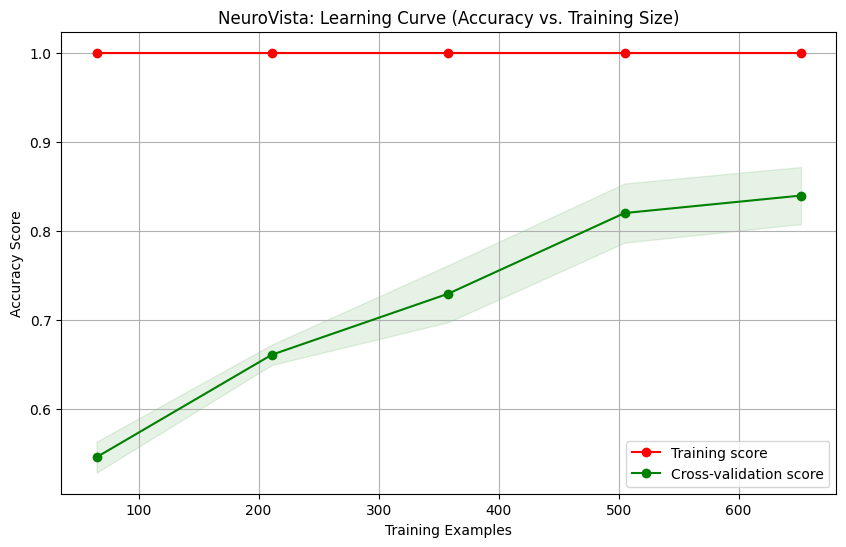

In [21]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, X, y):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=5, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 5), scoring='accuracy'
    )

    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_mean, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, test_mean, 'o-', color="g", label="Cross-validation score")

    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="g")

    plt.title("NeuroVista: Learning Curve (Accuracy vs. Training Size)")
    plt.xlabel("Training Examples")
    plt.ylabel("Accuracy Score")
    plt.legend(loc="best")
    plt.grid()
    plt.show()

# Run this to generate the plot
plot_learning_curve(ensemble, X_train_sel, y_train)